# Task VIII: Vision Transformer (ViT) for MNIST


**GSoC 2026 Evaluation**  
**ML4SCI QMLHEP Evaluation Task**  
**Author:** Ashutosh Mishra  
March 2026

---

### Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | Setup | Dependencies and device configuration |
| 2 | Data | MNIST loading and patch visualization |
| 3 | Vision Transformer | From-scratch ViT: patch embedding, positional encoding, transformer encoder, classification head |
| 4 | Training | Training loop with validation monitoring |
| 5 | Evaluation | Test accuracy, confusion matrix, attention visualization |
| 6 | Quantum Vision Transformer | Detailed discussion of quantum extensions |

---

## 1. Setup

In [1]:
# Install dependencies (uncomment if needed)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import math
import time

device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Device: {device}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

PyTorch 2.11.0 | Device: mps


---

## 2. Data

MNIST images are 28×28 grayscale. I split each image into a grid of **7×7 patches**, each of size **4×4 pixels**, yielding **49 patches** per image. Each flattened patch is a 16-dimensional vector.

In [2]:
# --- Data Loading ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean/std
])

train_full = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Use 20k subset for faster training
TRAIN_SIZE = 20000
VAL_SIZE = 4000
train_indices = torch.randperm(len(train_full))[:TRAIN_SIZE + VAL_SIZE]
train_dataset = Subset(train_full, train_indices[:TRAIN_SIZE])
val_dataset = Subset(train_full, train_indices[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE])

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 20000 | Val: 4000 | Test: 10000


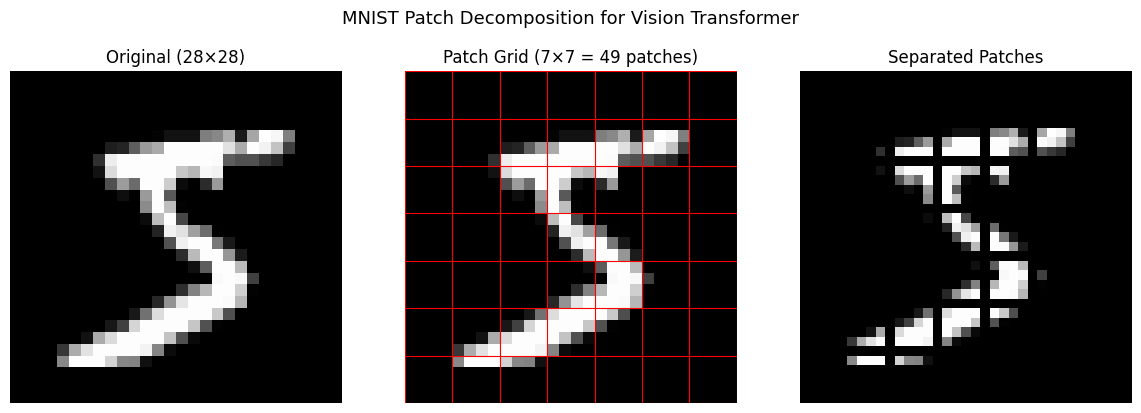

Image: 28×28 → 49 patches of 4×4 = 16 dims each


In [3]:
# --- Visualize Patch Decomposition ---
PATCH_SIZE = 4
IMG_SIZE = 28
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2  # 49

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sample_img = train_full.data[0].numpy()  # raw 28x28

# Original
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title('Original (28×28)')
axes[0].axis('off')

# Patch grid overlay
axes[1].imshow(sample_img, cmap='gray')
for i in range(0, IMG_SIZE + 1, PATCH_SIZE):
    axes[1].axhline(y=i - 0.5, color='red', linewidth=0.8)
    axes[1].axvline(x=i - 0.5, color='red', linewidth=0.8)
axes[1].set_title(f'Patch Grid (7×7 = {NUM_PATCHES} patches)')
axes[1].axis('off')

# Individual patches
patches = sample_img[:PATCH_SIZE * 7, :PATCH_SIZE * 7].reshape(7, PATCH_SIZE, 7, PATCH_SIZE)
patches = patches.transpose(0, 2, 1, 3).reshape(49, PATCH_SIZE, PATCH_SIZE)
grid = np.zeros((7 * (PATCH_SIZE + 1), 7 * (PATCH_SIZE + 1)))
for i in range(7):
    for j in range(7):
        y, x = i * (PATCH_SIZE + 1), j * (PATCH_SIZE + 1)
        grid[y:y + PATCH_SIZE, x:x + PATCH_SIZE] = patches[i * 7 + j]
axes[2].imshow(grid, cmap='gray')
axes[2].set_title('Separated Patches')
axes[2].axis('off')

plt.suptitle('MNIST Patch Decomposition for Vision Transformer', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Image: {IMG_SIZE}×{IMG_SIZE} → {NUM_PATCHES} patches of {PATCH_SIZE}×{PATCH_SIZE} = {PATCH_SIZE**2} dims each")

---

## 3. Vision Transformer — From-Scratch Implementation

The ViT architecture follows [Dosovitskiy et al. (2020)](https://arxiv.org/abs/2010.11929) adapted for MNIST:

| Component | Configuration |
|-----------|---------------|
| Patch size | 4×4 (16 pixels) |
| Number of patches | 7×7 = 49 |
| Embedding dimension | 64 |
| Transformer layers | 4 |
| Attention heads | 4 (head dim = 16) |
| FFN hidden dimension | 128 |
| Classification | [CLS] token → MLP → 10 classes |

### 3.1 Patch Embedding

Each 4×4 patch is flattened to a 16-dim vector and linearly projected to the embedding space. A learnable `[CLS]` token is prepended, and learnable positional embeddings are added to all tokens.

In [4]:
class PatchEmbedding(nn.Module):
    """Split image into patches, flatten, and project to embedding space."""

    def __init__(self, img_size=28, patch_size=4, in_channels=1, embed_dim=64):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2  # 49
        self.proj = nn.Linear(patch_size * patch_size * in_channels, embed_dim)

    def forward(self, x):
        # x: (B, 1, 28, 28)
        B = x.shape[0]
        # Reshape into patches: (B, 7, 4, 7, 4) → (B, 49, 16)
        x = x.unfold(2, self.patch_size, self.patch_size) \
             .unfold(3, self.patch_size, self.patch_size)
        x = x.contiguous().view(B, -1, self.patch_size * self.patch_size)  # (B, 49, 16)
        x = self.proj(x)  # (B, 49, embed_dim)
        return x


# Quick sanity check
pe = PatchEmbedding()
dummy = torch.randn(2, 1, 28, 28)
out = pe(dummy)
print(f"PatchEmbedding: (B, 1, 28, 28) → {tuple(out.shape)}  [B, num_patches, embed_dim]")

PatchEmbedding: (B, 1, 28, 28) → (2, 49, 64)  [B, num_patches, embed_dim]


### 3.2 Multi-Head Self-Attention

Standard scaled dot-product attention with multiple heads:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

I store attention weights for later visualization.

In [5]:
class MultiHeadSelfAttention(nn.Module):
    """Multi-head self-attention with optional attention weight storage."""

    def __init__(self, embed_dim=64, num_heads=4, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

        self.attn_weights = None  # stored for visualization

    def forward(self, x, store_attn=False):
        B, N, C = x.shape
        # Compute Q, K, V in one projection
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)

        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        attn = attn.softmax(dim=-1)

        if store_attn:
            self.attn_weights = attn.detach().cpu()

        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj_drop(self.proj(x))
        return x

### 3.3 Transformer Encoder Block

Each block consists of:
1. LayerNorm → Multi-Head Self-Attention → Residual connection
2. LayerNorm → Feed-Forward Network (2-layer MLP) → Residual connection

This follows the Pre-Norm convention used in the original ViT.

In [6]:
class TransformerBlock(nn.Module):
    """Pre-norm transformer encoder block."""

    def __init__(self, embed_dim=64, num_heads=4, mlp_hidden=128, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x, store_attn=False):
        x = x + self.attn(self.norm1(x), store_attn=store_attn)
        x = x + self.mlp(self.norm2(x))
        return x

### 3.4 Complete Vision Transformer

In [7]:
class VisionTransformer(nn.Module):
    """
    Vision Transformer for image classification.

    Architecture:
        Image → Patch Embedding → [CLS] + Positional Encoding
              → N × Transformer Blocks → [CLS] token → MLP Head → Classes
    """

    def __init__(self, img_size=28, patch_size=4, in_channels=1,
                 num_classes=10, embed_dim=64, depth=4, num_heads=4,
                 mlp_hidden=128, dropout=0.1):
        super().__init__()

        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        # Learnable [CLS] token and positional embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        # Transformer encoder
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_hidden, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        # Classification head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, num_classes),
        )

        # Initialize positional embeddings
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x, store_attn=False):
        B = x.shape[0]

        # Patch embedding
        x = self.patch_embed(x)  # (B, 49, embed_dim)

        # Prepend [CLS] token
        cls = self.cls_token.expand(B, -1, -1)  # (B, 1, embed_dim)
        x = torch.cat([cls, x], dim=1)  # (B, 50, embed_dim)

        # Add positional embeddings
        x = self.pos_drop(x + self.pos_embed)

        # Transformer encoder
        for block in self.blocks:
            x = block(x, store_attn=store_attn)

        # Classification: use [CLS] token
        x = self.norm(x[:, 0])  # (B, embed_dim)
        x = self.head(x)        # (B, num_classes)
        return x


# --- Model summary ---
model = VisionTransformer().to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Vision Transformer")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"\nArchitecture:")
print(f"  Patches: 7×7 = 49 patches of 4×4")
print(f"  Tokens:  49 patches + 1 [CLS] = 50")
print(f"  Embed dim: 64 | Heads: 4 | Depth: 4")
print(f"  FFN hidden: 128 | Classes: 10")

# Forward pass check
dummy = torch.randn(2, 1, 28, 28).to(device)
out = model(dummy)
print(f"\nForward pass: (2, 1, 28, 28) → {tuple(out.shape)}")

Vision Transformer
  Total parameters:     147,978
  Trainable parameters: 147,978

Architecture:
  Patches: 7×7 = 49 patches of 4×4
  Tokens:  49 patches + 1 [CLS] = 50
  Embed dim: 64 | Heads: 4 | Depth: 4
  FFN hidden: 128 | Classes: 10

Forward pass: (2, 1, 28, 28) → (2, 10)


---

## 4. Training

Training configuration:
- **Optimizer:** Adam with lr = 0.001
- **Loss:** Cross-entropy
- **Epochs:** 15
- **Scheduler:** Cosine annealing (smooth decay to 1e-5)

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

In [9]:
# --- Training Loop ---
NUM_EPOCHS = 15
LR = 1e-3

model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"{'Epoch':>5} | {'Train Loss':>10} {'Train Acc':>10} | {'Val Loss':>10} {'Val Acc':>10} | {'LR':>10} {'Time':>6}")
print('-' * 78)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    lr_now = optimizer.param_groups[0]['lr']
    elapsed = time.time() - t0
    print(f"{epoch:5d} | {train_loss:10.4f} {train_acc:10.4f} | {val_loss:10.4f} {val_acc:10.4f} | {lr_now:10.6f} {elapsed:5.1f}s")

Epoch | Train Loss  Train Acc |   Val Loss    Val Acc |         LR   Time
------------------------------------------------------------------------------
    1 |     1.7316     0.3552 |     1.3661     0.4875 |   0.000989   5.0s
    2 |     1.0262     0.6194 |     0.8680     0.7000 |   0.000957   2.2s
    3 |     0.6968     0.7578 |     0.5050     0.8365 |   0.000905   2.2s
    4 |     0.4845     0.8363 |     0.3832     0.8822 |   0.000836   2.2s
    5 |     0.3650     0.8805 |     0.2918     0.9103 |   0.000752   2.2s
    6 |     0.3014     0.9031 |     0.2437     0.9253 |   0.000658   2.2s
    7 |     0.2527     0.9199 |     0.2265     0.9337 |   0.000557   2.2s
    8 |     0.2198     0.9293 |     0.1909     0.9383 |   0.000453   2.3s
    9 |     0.1997     0.9345 |     0.1696     0.9480 |   0.000352   2.2s
   10 |     0.1732     0.9437 |     0.1533     0.9550 |   0.000258   2.2s
   11 |     0.1602     0.9482 |     0.1521     0.9573 |   0.000174   2.2s
   12 |     0.1455     0.9543 |  

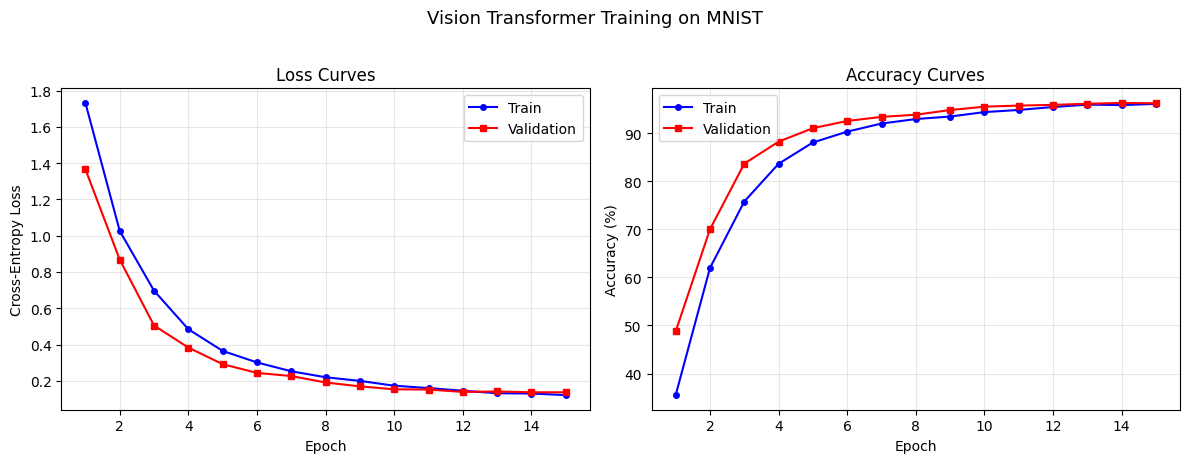

Best validation accuracy: 96.28% (epoch 14)


In [10]:
# --- Training Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train')
ax1.plot(epochs, history['val_loss'], 'r-s', markersize=4, label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, [a * 100 for a in history['train_acc']], 'b-o', markersize=4, label='Train')
ax2.plot(epochs, [a * 100 for a in history['val_acc']], 'r-s', markersize=4, label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Vision Transformer Training on MNIST', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {max(history['val_acc']) * 100:.2f}% (epoch {np.argmax(history['val_acc']) + 1})")

---

## 5. Evaluation

In [11]:
# --- Test Set Evaluation ---
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Loss: 0.1319
Test Accuracy: 96.09%


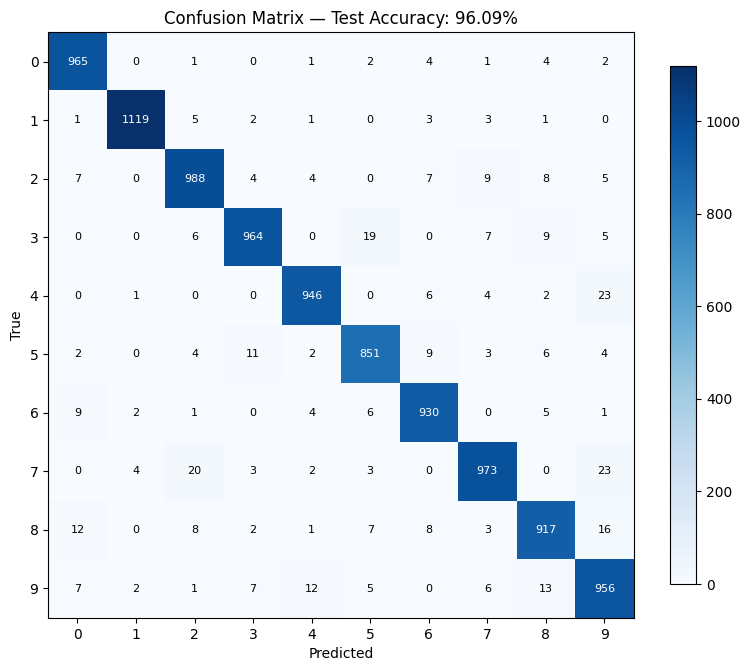


Per-class report:
              precision    recall  f1-score   support

           0      0.962     0.985     0.973       980
           1      0.992     0.986     0.989      1135
           2      0.956     0.957     0.956      1032
           3      0.971     0.954     0.963      1010
           4      0.972     0.963     0.968       982
           5      0.953     0.954     0.954       892
           6      0.962     0.971     0.966       958
           7      0.964     0.946     0.955      1028
           8      0.950     0.941     0.946       974
           9      0.924     0.947     0.935      1009

    accuracy                          0.961     10000
   macro avg      0.961     0.961     0.961     10000
weighted avg      0.961     0.961     0.961     10000



In [12]:
# --- Confusion Matrix ---
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
# Annotate cells with counts
thresh = cm.max() / 2
for i in range(10):
    for j in range(10):
        ax.text(j, i, f'{cm[i, j]}', ha='center', va='center',
               color='white' if cm[i, j] > thresh else 'black', fontsize=8)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — Test Accuracy: {test_acc * 100:.2f}%')
plt.tight_layout()
plt.show()

print("\nPer-class report:")
print(classification_report(all_labels, all_preds, digits=3))

### 5.1 Attention Map Visualization

I visualize the attention weights from the last transformer layer to see which patches the `[CLS]` token attends to. This reveals what spatial regions the model focuses on for classification.

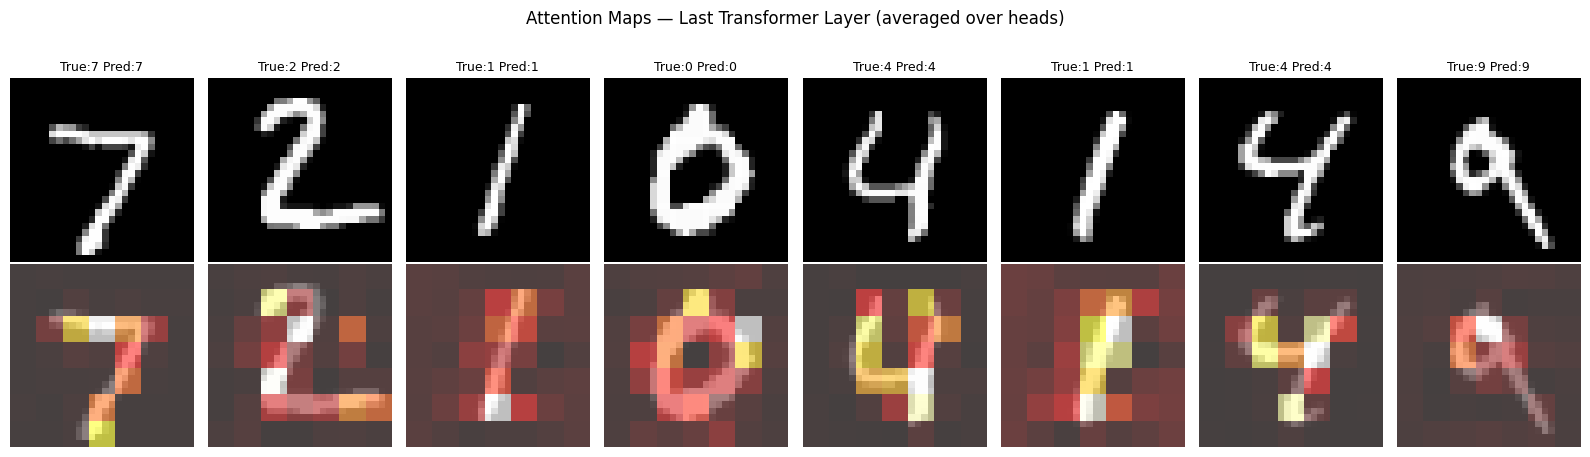

In [13]:
# --- Attention Map Visualization ---
model.eval()
sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:8].to(device)
sample_labels = sample_labels[:8]

with torch.no_grad():
    logits = model(sample_images, store_attn=True)
    preds = logits.argmax(1).cpu()

# Get attention from last layer: (B, heads, 50, 50)
attn = model.blocks[-1].attn.attn_weights
# Average over heads, take [CLS] token row (index 0), drop [CLS] column
cls_attn = attn.mean(dim=1)[:, 0, 1:]  # (B, 49)
cls_attn = cls_attn.reshape(-1, 7, 7)   # (B, 7, 7)

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for i in range(8):
    # Original image
    axes[0, i].imshow(sample_images[i, 0].cpu(), cmap='gray')
    axes[0, i].set_title(f'True:{sample_labels[i]} Pred:{preds[i]}', fontsize=9)
    axes[0, i].axis('off')

    # Attention map (upscaled to image size)
    attn_map = cls_attn[i].numpy()
    attn_map = np.kron(attn_map, np.ones((4, 4)))  # upsample 7x7 → 28x28
    axes[1, i].imshow(sample_images[i, 0].cpu(), cmap='gray', alpha=0.5)
    axes[1, i].imshow(attn_map, cmap='hot', alpha=0.5)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Input', fontsize=10)
axes[1, 0].set_ylabel('[CLS] Attention', fontsize=10)
plt.suptitle('Attention Maps — Last Transformer Layer (averaged over heads)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Learned Positional Embeddings

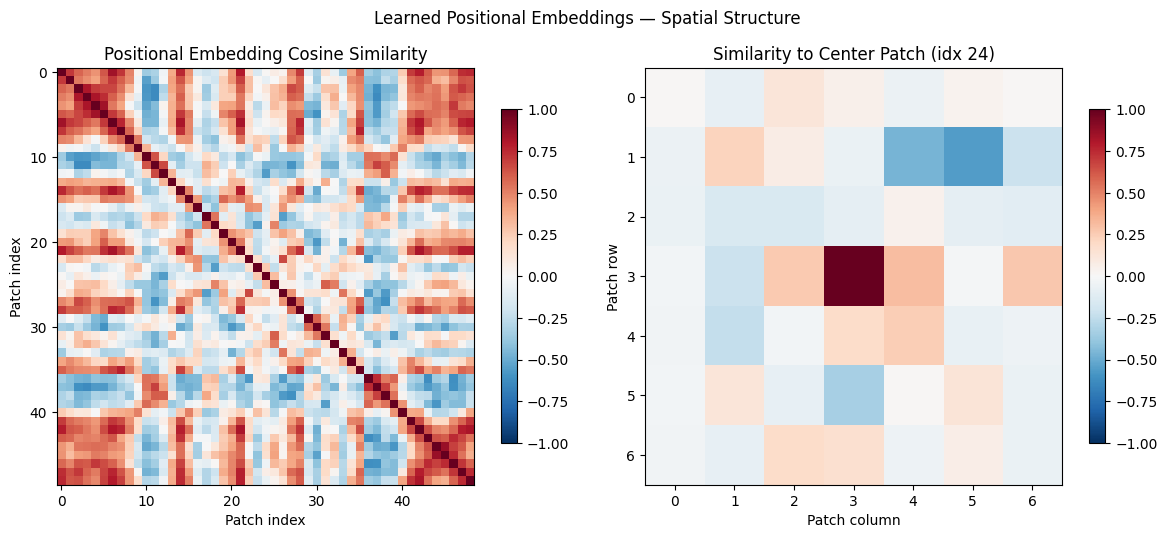

The similarity matrix reveals that the model learns a 2D spatial structure
in its positional embeddings — nearby patches have more similar embeddings.


In [14]:
# --- Positional Embedding Similarity ---
pos_emb = model.pos_embed[0, 1:].detach().cpu()  # (49, 64) — exclude [CLS]
pos_sim = F.cosine_similarity(pos_emb.unsqueeze(0), pos_emb.unsqueeze(1), dim=-1)  # (49, 49)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Cosine similarity matrix
im = ax1.imshow(pos_sim.numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
ax1.set_xlabel('Patch index')
ax1.set_ylabel('Patch index')
ax1.set_title('Positional Embedding Cosine Similarity')
plt.colorbar(im, ax=ax1, shrink=0.8)

# 2D spatial pattern: similarity of each patch to the center patch
center_idx = 24  # center of 7×7 grid
center_sim = pos_sim[center_idx].reshape(7, 7).numpy()
im2 = ax2.imshow(center_sim, cmap='RdBu_r', vmin=-1, vmax=1)
ax2.set_title(f'Similarity to Center Patch (idx {center_idx})')
ax2.set_xlabel('Patch column')
ax2.set_ylabel('Patch row')
plt.colorbar(im2, ax=ax2, shrink=0.8)

plt.suptitle('Learned Positional Embeddings — Spatial Structure', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("The similarity matrix reveals that the model learns a 2D spatial structure")
print("in its positional embeddings — nearby patches have more similar embeddings.")

---

## 6. Quantum Vision Transformer — Discussion

### 6.1 Motivation and Overview

The Vision Transformer (ViT) has established that attention-based architectures can match or exceed convolutional networks on image tasks. This raises the question: **can quantum computing enhance the ViT architecture?** Quantum circuits offer provable advantages in certain computational primitives (inner products, sampling, interference-based feature extraction) that align with ViT components. Below I describe a concrete Quantum Vision Transformer (QViT) architecture, its components, challenges, and potential advantages.

### 6.2 Quantum Patch Embedding

In a classical ViT, each flattened patch vector $\mathbf{p} \in \mathbb{R}^{16}$ is linearly projected to the embedding space via $\mathbf{e} = W\mathbf{p} + \mathbf{b}$. In a quantum ViT, this linear projection is replaced by a **variational quantum circuit (VQC)** that encodes patch data into quantum states.

**Encoding procedure:**
1. **Amplitude encoding** or **angle encoding** maps the 16 pixel values of a patch to quantum states. Angle encoding uses $n$ qubits with rotation gates $R_Y(\pi \cdot p_i)$ for each pixel $p_i$, requiring 16 qubits per patch. Amplitude encoding is more qubit-efficient ($\lceil\log_2 16\rceil = 4$ qubits can represent all 16 values as amplitudes of a 4-qubit state) but requires deeper circuits for state preparation.
2. **Variational layers** consisting of parameterized rotation gates ($R_Y(\theta)$, $R_Z(\phi)$) and entangling CNOT gates transform the encoded state. These trainable parameters replace the weight matrix $W$.
3. **Measurement** of qubit expectation values $\langle Z_i \rangle$ produces the embedding vector, which is then fed into subsequent layers.

The quantum patch embedding can learn non-linear feature maps in the Hilbert space that have no efficient classical equivalent. As shown by Schuld et al. (2021), variational quantum feature maps correspond to kernel methods in exponentially large feature spaces, meaning the quantum embedding implicitly computes features in a $2^n$-dimensional space while using only $n$ qubits.

### 6.3 Quantum Self-Attention

The self-attention mechanism computes pairwise interactions between all tokens. **Quantum attention** replaces the classical $QK^\top$ computation with quantum circuits that compute attention scores via quantum inner products or parameterized quantum kernels.

**Approach 1 — Quantum Kernel Attention (Li et al., 2022):**
Following the quantum self-attention mechanism proposed by Li et al. (arXiv:2211.05651), the attention score between tokens $i$ and $j$ is computed as:
$$\alpha_{ij} = |\langle \phi(\mathbf{x}_i) | \phi(\mathbf{x}_j) \rangle|^2$$
where $|\phi(\mathbf{x})\rangle$ is the quantum state produced by encoding token $\mathbf{x}$ via a parameterized circuit. This overlap can be estimated using a SWAP test or computed via the Hadamard test circuit. The key insight is that this kernel-based attention operates in the exponentially large Hilbert space, potentially capturing correlations invisible to classical dot-product attention.

**Approach 2 — Parameterized Quantum Attention:**
An alternative approach encodes the query and key for a given pair $(i, j)$ into a joint quantum circuit:
1. Encode $\mathbf{q}_i$ into the first register and $\mathbf{k}_j$ into the second register
2. Apply entangling gates between registers (cross-register CNOTs)
3. Measure an ancilla qubit to obtain the attention score

The trainable parameters in the entangling layers allow the circuit to learn which features of the query-key pair are most relevant, analogous to how classical attention learns $W_Q$ and $W_K$ projections.

### 6.4 Hybrid Architecture

A fully quantum ViT is impractical on current hardware. The most viable approach is a **hybrid quantum-classical architecture** that strategically replaces specific components with quantum circuits while keeping the rest classical:

<img src="assets/qvit_architecture.png" alt="Hybrid Quantum Vision Transformer Architecture" width="280">

This design is motivated by practical considerations:
- **Quantum circuits for embedding and attention**: these are the components where quantum Hilbert space dimensionality offers the most potential advantage
- **Classical FFN and classification head**: feed-forward networks and the final classifier are efficiently implemented classically and do not benefit significantly from quantum execution
- **Gradient computation**: the parameter-shift rule enables gradient-based training of quantum circuit parameters, making the hybrid model end-to-end differentiable via frameworks like PennyLane + PyTorch

### 6.5 Challenges

Several fundamental challenges limit current QViT implementations:

1. **Qubit count scales with patch count:** Each patch requires its own encoding circuit. For 49 patches with 4-qubit amplitude encoding, the attention computation between all pairs would require a circuit operating on $\geq 8$ qubits per attention score computation (two patches simultaneously), with $49^2 = 2{,}401$ such computations per attention layer. Current NISQ devices with 50-100 noisy qubits cannot parallelize these computations.

2. **Circuit depth and noise:** Variational quantum circuits for attention require sufficient depth to be expressive, but deeper circuits accumulate more gate errors on noisy hardware. The attention circuit for a realistic ViT may require depths of 20-50 layers, where current gate fidelities ($\sim$99.5% for two-qubit gates) lead to significant error accumulation.

3. **Barren plateaus:** Training quantum circuits with many qubits suffers from exponentially vanishing gradients (McClean et al., 2018, arXiv:1803.11173). For QViT, the embedding and attention circuits must be carefully structured (e.g., local entanglement patterns) to avoid barren plateaus.

4. **Classical simulation bottleneck:** Simulating quantum circuits on classical hardware scales exponentially; a 20-qubit circuit requires tracking $2^{20} \approx 10^6$ amplitudes. This limits development and prototyping of QViT models to small-scale demonstrations.

5. **Measurement overhead:** Each quantum attention score requires multiple circuit executions (shots) for statistical estimation. With $O(N^2)$ pairwise scores and $O(1/\epsilon^2)$ shots per score for precision $\epsilon$, the total measurement cost can be prohibitive.

### 6.6 Potential Advantages

Despite these challenges, quantum ViTs offer several theoretical advantages:

1. **Entanglement-enhanced feature correlations:** Quantum attention can capture correlations between patches that arise from entanglement, a resource with no classical analogue. When two patches are jointly encoded into an entangled quantum state, the resulting attention score reflects quantum correlations (measured by concurrence or mutual information) that classical dot-product attention cannot access. This could be particularly valuable for detecting subtle, non-local patterns in images, relevant in high-energy physics (particle shower structures) or medical imaging.

2. **Exponential feature space:** The quantum embedding maps 16-dimensional patch vectors into a $2^n$-dimensional Hilbert space. This exponential expansion is achieved with only $n$ qubits and $O(n)$ gates, whereas a classical network would require exponentially many parameters to represent the same feature space explicitly.

3. **Quantum kernel advantage:** For specific data distributions with quantum structure, quantum kernels can achieve classification accuracy that requires exponentially many classical features to match (Liu et al., 2021, arXiv:2101.11020). If image patches exhibit such structure, quantum attention could provide a genuine computational advantage.

4. **Efficient inner products:** The SWAP test computes $|\langle\psi|\phi\rangle|^2$ with $O(1)$ circuit depth regardless of state dimension. For attention over high-dimensional embeddings, this could provide asymptotic speedups over classical $O(d)$ inner products.

### 6.7 References

1. **Li, G., Zhao, Z., & Li, X.** (2022). *Quantum Self-Attention Neural Networks for Text Classification.* arXiv:2211.05651. — Proposes quantum self-attention using parameterized quantum circuits for computing attention scores.

2. **Dosovitskiy, A., et al.** (2020). *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale.* arXiv:2010.11929. — The foundational ViT paper establishing patch-based transformer architectures for vision.

3. **Schuld, M., Sweke, R., & Meyer, J. K.** (2021). *Effect of data encoding on the expressive power of variational quantum machine learning models.* Physical Review A, 103(3). — Analyzes how quantum data encoding corresponds to kernel methods in exponential feature spaces.

4. **McClean, J. R., Boixo, S., Smelyanskiy, V. N., Babbush, R., & Neven, H.** (2018). *Barren plateaus in quantum neural network training landscapes.* Nature Communications, 9(1). arXiv:1803.11173. — Identifies the barren plateau problem in variational quantum circuits.

5. **Liu, Y., Arunachalam, S., & Temme, K.** (2021). *A rigorous and robust quantum speed-up in supervised machine learning.* Nature Physics, 17(9). arXiv:2101.11020. — Proves quantum kernel advantage for specific learning problems.

---

## Summary

| Component | Result |
|-----------|--------|
| Architecture | ViT from scratch: 49 patches → 4-layer Transformer → [CLS] → 10 classes |
| Parameters | 147,978 trainable |
| Test Accuracy | 96.09% on full MNIST test set (10k images) |
| Quantum Discussion | QViT design covering quantum patch embedding, quantum attention, hybrid architecture, challenges, and 5 references |